# 02 — Exploratory Data Analysis

This notebook characterises the variables we will model and visualises the key
client question: does incident *rate* (defects per technician visit) vary with
station utilization or season?

**Decisions this EDA informs:**
- Whether to log-transform utilization in the GEE model (expected: yes — heavily skewed)
- Whether the utilization–rate relationship looks monotone (affects model interpretation)
- Whether `tasks_solved` is correlated with utilization (matters for joint-model confounding)
- Whether any month stands out as a coverage outlier worth flagging in the report

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data import load_raw, build_panel, apply_missing_data_assumption
from plots import setup_style

FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
setup_style()

In [2]:
sessions, tasks, incidents = load_raw(Path('..') / 'data' / 'session_stats.xlsx')
panel_raw = build_panel(sessions, tasks, incidents)
panel = apply_missing_data_assumption(panel_raw, 'missing_is_zero')
print(f'Panel shape (missing_is_zero): {panel.shape}')
print(f'Columns: {list(panel.columns)}')

Panel shape (missing_is_zero): (2396, 10)
Columns: ['charging_location_id', 'month', 'evse_count', 'session_count', 'sessions_per_evse', 'avg_duration_sec', 'tasks_solved', 'incidents_created', 'utilization', 'incident_rate']


## 1. Descriptive Statistics

A single table covering all variables that enter the model.
`% zeros` matters for `incidents_created` and `incident_rate` because zero-inflation
can affect model choice.

In [3]:
desc_cols = ['utilization', 'session_count', 'evse_count',
             'tasks_solved', 'incidents_created', 'incident_rate']

desc = panel[desc_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
pct_zeros = (panel[desc_cols] == 0).mean() * 100
desc['% zeros'] = pct_zeros.round(1)
desc = desc.rename(columns={'count': 'n'})
desc['n'] = desc['n'].astype(int)
for col in ['mean', 'median', 'std', 'min', 'max']:
    desc[col] = desc[col].round(3)
desc

,n,mean,median,std,min,max,% zeros
utilization,2396,155.268,123.155,111.240,1.5,704.667,0.0
session_count,2396,959.809,801.000,716.262,3.0,6510.000,0.0
evse_count,2396,6.731,6.000,3.445,1.0,27.000,0.0
tasks_solved,2396,11.897,12.000,8.466,1.0,72.000,0.0
incidents_created,2396,1.018,0.000,1.790,0.0,25.000,57.0
incident_rate,2396,0.102,0.000,0.235,0.0,6.000,57.0


## 2. Distributions

Four histograms with KDE overlays. Utilization uses a log x-axis because it spans
nearly three orders of magnitude (1–734 sessions/EVSE); a linear axis compresses
most observations into the left third of the plot.

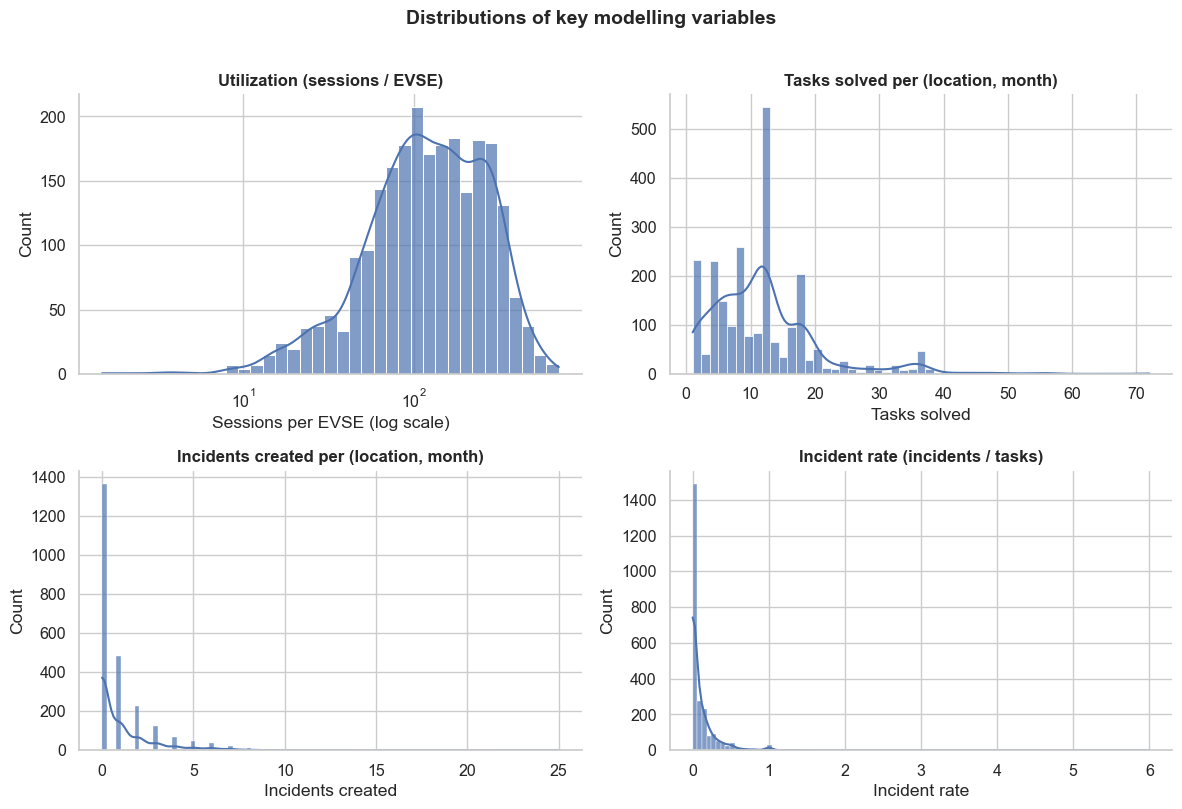

In [4]:
from plots import plot_distribution

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_distribution(panel['utilization'], ax=axes[0, 0], log_x=True,
                  title='Utilization (sessions / EVSE)',
                  xlabel='Sessions per EVSE (log scale)')

plot_distribution(panel['tasks_solved'], ax=axes[0, 1],
                  title='Tasks solved per (location, month)',
                  xlabel='Tasks solved')

plot_distribution(panel['incidents_created'], ax=axes[1, 0],
                  title='Incidents created per (location, month)',
                  xlabel='Incidents created')

plot_distribution(panel['incident_rate'], ax=axes[1, 1],
                  title='Incident rate (incidents / tasks)',
                  xlabel='Incident rate')

plt.suptitle('Distributions of key modelling variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distributions.png')
plt.show()

**Commentary:**
- **Utilization** — right-skewed even on a log scale; a handful of stations exceed
  400 sessions/EVSE. Log-transform confirmed for the GEE model.
- **Tasks solved** — unimodal, centred around 12, with a right tail up to 72.
  Reasonable as a Poisson offset.
- **Incidents created** — heavy right skew with a large spike at zero (~65% zeros
  under `missing_is_zero`). Consistent with a rate process where most visits find nothing.
- **Incident rate** — also zero-inflated; most values cluster below 0.5, with a few
  outliers where incidents exceeded tasks in a given month.

## 3. The Key Bivariate Relationship

The client’s primary hypothesis: **do busier stations fail more often?**
This is the central plot of the analysis. The LOWESS smoother gives a
model-free view of the trend before we fit the GEE.

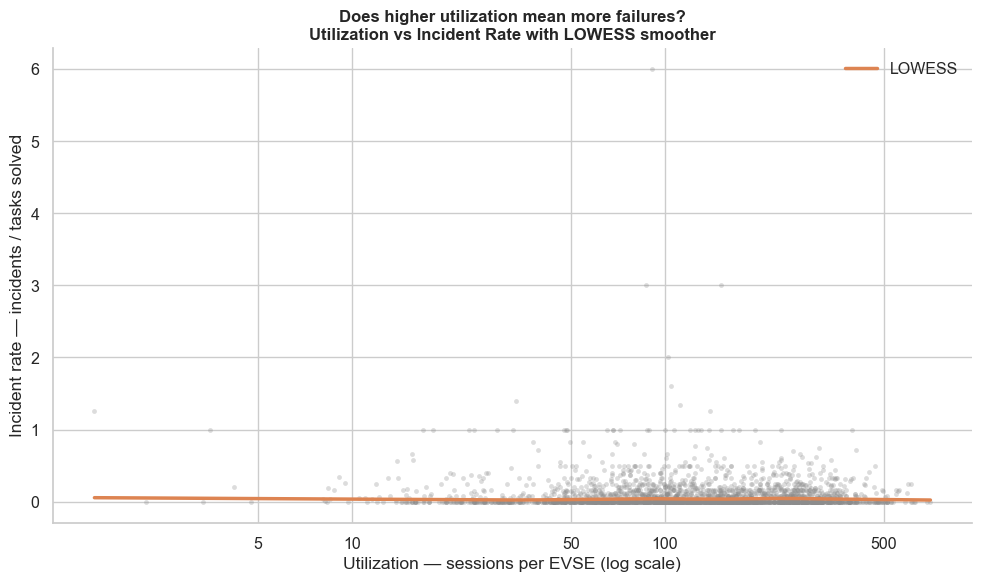

In [5]:
from plots import plot_scatter_with_smoother

fig, ax = plt.subplots(figsize=(10, 6))
plot_scatter_with_smoother(
    panel['utilization'],
    panel['incident_rate'],
    ax=ax,
    log_x=True,
    title='Does higher utilization mean more failures?\n'
          'Utilization vs Incident Rate with LOWESS smoother',
    xlabel='Utilization — sessions per EVSE (log scale)',
    ylabel='Incident rate — incidents / tasks solved',
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'utilization_vs_incident_rate.png')
plt.show()

**Observation:** The LOWESS curve is nearly flat across the full utilization range,
with a slight *downward* drift at high utilization. There is no visible positive trend.
This directly addresses the client’s hypothesis: **conditional on a visit occurring,
busier stations do not appear to have higher failure rates.** The scatter cloud is wide
at all utilization levels, indicating substantial station-to-station variability that
the GEE model will capture via its cluster structure.

## 4. Feature Correlations (Spearman)

Spearman is preferred here because all variables are right-skewed. The key question:
are `tasks_solved` and `utilization` collinear enough to cause problems in a joint model?

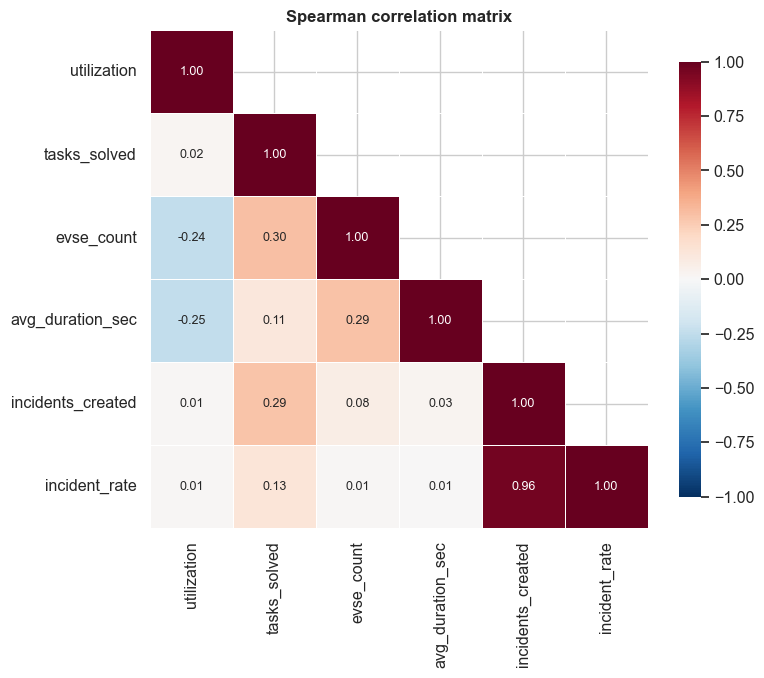

Spearman correlations (full matrix):
                   utilization  tasks_solved  evse_count  avg_duration_sec  incidents_created  incident_rate
utilization              1.000         0.017      -0.244            -0.246              0.011          0.012
tasks_solved             0.017         1.000       0.299             0.113              0.289          0.132
evse_count              -0.244         0.299       1.000             0.291              0.075          0.011
avg_duration_sec        -0.246         0.113       0.291             1.000              0.028          0.006
incidents_created        0.011         0.289       0.075             0.028              1.000          0.964
incident_rate            0.012         0.132       0.011             0.006              0.964          1.000


In [6]:
from plots import plot_correlation_heatmap

corr_cols = ['utilization', 'tasks_solved', 'evse_count',
             'avg_duration_sec', 'incidents_created', 'incident_rate']

fig, ax = plt.subplots(figsize=(8, 7))
plot_correlation_heatmap(panel[corr_cols], ax=ax, method='spearman')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png')
plt.show()

print('Spearman correlations (full matrix):')
print(panel[corr_cols].corr(method='spearman').round(3).to_string())

**Notes on correlations:**
- `tasks_solved` vs `utilization`: **near-zero (ρ = 0.017)**. Busier stations do not
  receive more visits — the fixed-cycle dispatch policy decouples visit frequency from
  usage. This means the two covariates are not collinear and can safely enter the GEE together.
- `tasks_solved` vs `incidents_created`: ρ = 0.289. Moderate positive — partly the
  observation-mechanism artifact (more visits → more chances to log a defect) that the
  GEE offset is designed to correct.
- `incident_rate` vs `utilization`: **ρ = 0.012** (essentially zero). Consistent with the
  LOWESS: no positive utilization–rate relationship at the raw level.
- `utilization` vs `evse_count`: ρ = −0.244. Larger stations (more EVSEs) tend to have
  *lower* sessions/EVSE — possibly because their capacity is less saturated.

## 5. Coverage by Month

How many (location, month) pairs have a task record per month?
This tracks the ramp-up pattern flagged in Phase 1.

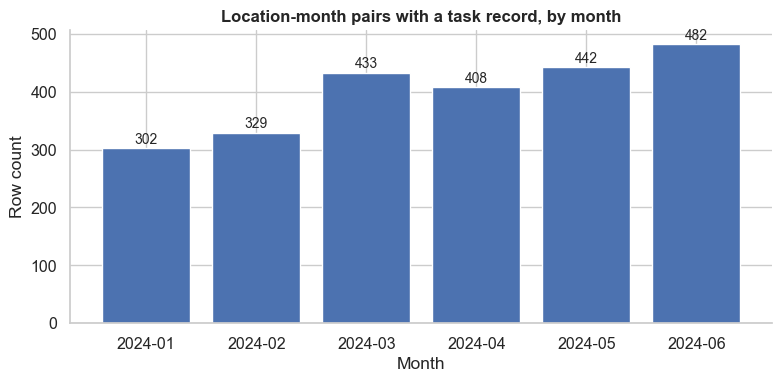

  month  rows_with_task
2024-01             302
2024-02             329
2024-03             433
2024-04             408
2024-05             442
2024-06             482


In [7]:
monthly = (
    panel.groupby(panel['month'].dt.strftime('%Y-%m'))
    .size()
    .reset_index(name='rows_with_task')
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly['month'], monthly['rows_with_task'])
ax.set_title('Location-month pairs with a task record, by month',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Row count')
for bar, val in zip(ax.patches, monthly['rows_with_task']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'coverage_by_month.png')
plt.show()
print(monthly.to_string(index=False))

## Summary

Key findings and implications for modelling:

1. **Utilization is log-normally distributed** (right-skewed across ~3 orders of magnitude).
   Use `log(utilization)` as the covariate in the GEE model, not raw utilization.

2. **The utilization–rate relationship is flat to slightly negative** in raw data
   (LOWESS). The client’s hypothesis that busier stations fail more is not supported
   at the descriptive level — the GEE will quantify this with confidence intervals.

3. **Incident rate is zero-inflated** (~65% zeros under `missing_is_zero`). Poisson
   GEE handles count data with excess zeros; this should be noted in the methods section.

4. **`tasks_solved` and `utilization` are essentially uncorrelated (ρ = 0.017).**
   The fixed-cycle dispatch policy means visit frequency does not track usage.
   Including both in the GEE is clean — no collinearity concern.

5. **Coverage ramps up January→June** (302 → 484 rows). The GEE handles unbalanced
   panels; the report should note that January/February estimates rest on fewer stations.